
BEST CATBOOST CONFIGURATION
Best CV NSE: 0.4857571106079469
{'depth': 4, 'learning_rate': 0.01, 'iterations': 800, 'l2_leaf_reg': 1}

CATBOOST PERFORMANCE (Q_MIN)
RMSE: 26.28
MAE : 18.71
NSE : 0.4319


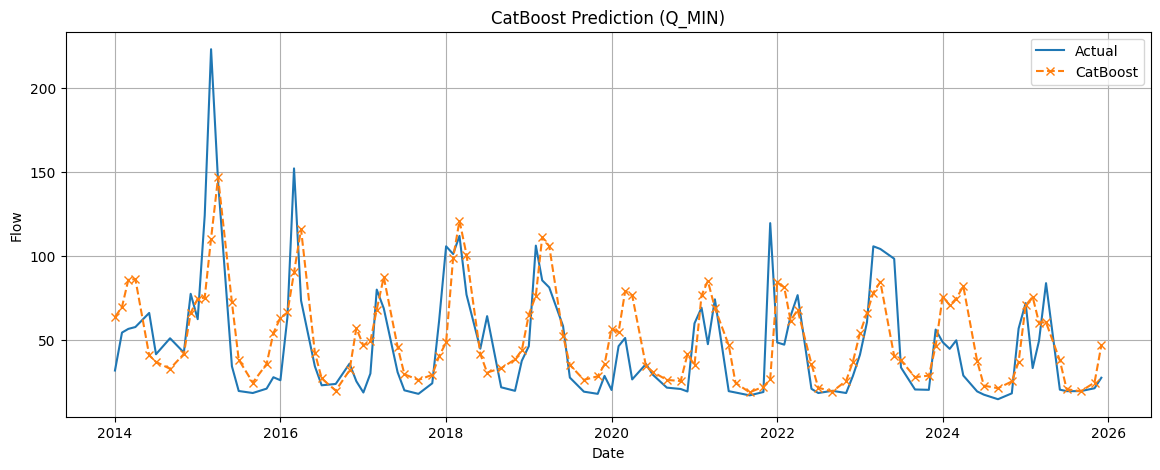

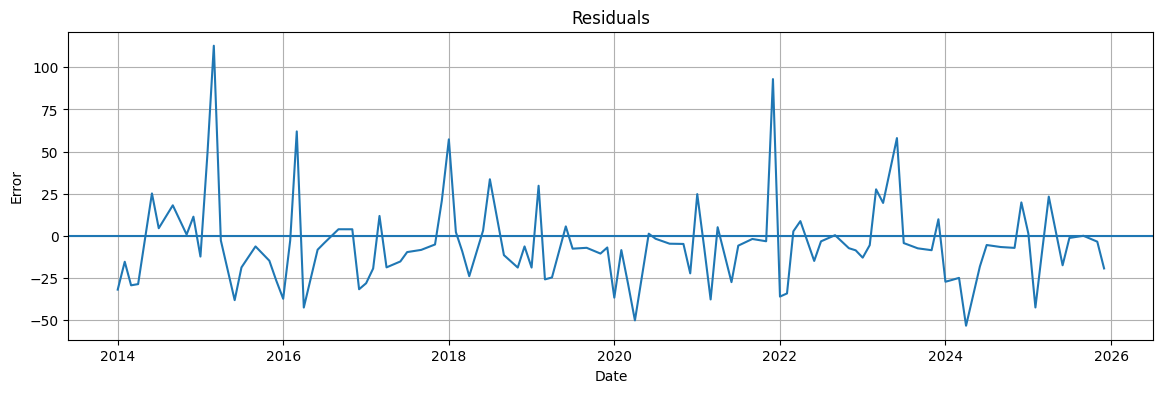

In [3]:
# ==========================================================
# CATBOOST TIME-SERIES FORECASTING PIPELINE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================================
# 1. PREPARE TIME SERIES
# ==========================================================

def prepare_time_series(df, value_name='flow'):

    df = df.copy()

    df.columns = df.columns.str.strip().str.lower()

    months = [
        "jan","feb","mar","apr","maj","jun",
        "jul","avg","sep","okt","nov","dec"
    ]

    existing_months = [m for m in months if m in df.columns]

    # numeric conversion
    df[existing_months] = df[existing_months].apply(
        pd.to_numeric,
        errors='coerce'
    )

    # fill missing
    df[existing_months] = (
        df[existing_months]
        .ffill()
        .bfill()
    )

    # melt to long format
    ts = df.melt(
        id_vars='year',
        value_vars=existing_months,
        var_name='month',
        value_name=value_name
    )

    # datetime
    ts['date'] = pd.to_datetime(
        ts['year'].astype(str) + '-' + ts['month'],
        format='%Y-%b',
        errors='coerce'
    )

    ts = ts.dropna(subset=['date'])

    ts = ts.set_index('date').sort_index()

    ts = ts.dropna(subset=[value_name])

    # ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)

    return ts


# ==========================================================
# 2. PREPARE ML DATA
# ==========================================================

def prepare_ml_data(ts,
                    window_size=12,
                    split_date='2014-01-01'):

    ts = ts.copy()

    ts['flow'] = ts['flow'].clip(lower=0)

    # seasonal features
    ts['sin_month'] = np.sin(
        2 * np.pi * ts.index.month / 12
    )

    ts['cos_month'] = np.cos(
        2 * np.pi * ts.index.month / 12
    )

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []

    for i in range(window_size, len(flows)):

        lag_vals = flows[i-window_size:i]

        features = np.concatenate([
            lag_vals,
            [sin_m[i], cos_m[i]]
        ])

        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # log transform
    y_log = np.log1p(y)

    # chronological split
    split_date = pd.to_datetime(split_date)

    split_idx = np.where(idx < split_date)[0]

    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],
        "idx_test": idx[split:]
    }


# ==========================================================
# 3. NSE
# ==========================================================

def nse(y_true, y_pred):

    denom = np.sum(
        (y_true - np.mean(y_true))**2
    )

    if denom == 0:
        return 0

    return 1 - np.sum(
        (y_true - y_pred)**2
    ) / denom


# ==========================================================
# 4. METRICS
# ==========================================================

def compute_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(y_true, y_pred)

    nse_val = nse(y_true, y_pred)

    return rmse, mae, nse_val


# ==========================================================
# 5. TUNE CATBOOST
# ==========================================================

def tune_catboost(X_train, y_train):

    param_grid = {

        'depth': [4, 6, 8],

        'learning_rate': [0.01, 0.03, 0.05],

        'iterations': [300, 500, 800],

        'l2_leaf_reg': [1, 3, 5]
    }

    tscv = TimeSeriesSplit(n_splits=5)

    best_score = -np.inf
    best_model = None
    best_params = None

    import itertools

    for depth, lr, iterations, l2 in itertools.product(
        param_grid['depth'],
        param_grid['learning_rate'],
        param_grid['iterations'],
        param_grid['l2_leaf_reg']
    ):

        scores = []

        for train_idx, val_idx in tscv.split(X_train):

            X_tr = X_train[train_idx]
            X_val = X_train[val_idx]

            y_tr = y_train[train_idx]
            y_val = y_train[val_idx]

            model = CatBoostRegressor(

                depth=depth,

                learning_rate=lr,

                iterations=iterations,

                l2_leaf_reg=l2,

                loss_function='RMSE',

                verbose=False,

                random_seed=42
            )

            model.fit(X_tr, y_tr)

            # validation prediction
            y_pred_log = model.predict(X_val)

            # inverse transform
            y_pred = np.expm1(y_pred_log)

            y_true = np.expm1(y_val)

            score = nse(y_true, y_pred)

            scores.append(score)

        avg_score = np.mean(scores)

        if avg_score > best_score:

            best_score = avg_score

            best_params = {
                'depth': depth,
                'learning_rate': lr,
                'iterations': iterations,
                'l2_leaf_reg': l2
            }

    print("\n===================================")
    print("BEST CATBOOST CONFIGURATION")
    print("===================================")

    print("Best CV NSE:", best_score)
    print(best_params)

    # retrain on full train
    best_model = CatBoostRegressor(

        depth=best_params['depth'],

        learning_rate=best_params['learning_rate'],

        iterations=best_params['iterations'],

        l2_leaf_reg=best_params['l2_leaf_reg'],

        loss_function='RMSE',

        verbose=False,

        random_seed=42
    )

    best_model.fit(X_train, y_train)

    return best_model


# ==========================================================
# 6. TEST CATBOOST
# ==========================================================

def test_catboost(model, data, label="Q_MIN"):

    X_test = data["X_test"]
    y_test = data["y_test"]
    idx = data["idx_test"]

    # predict
    y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)

    # enforce non-negative
    y_pred = np.maximum(y_pred, 0)

    # align
    min_len = min(len(y_test), len(y_pred))

    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # metrics
    rmse, mae, nse_val = compute_metrics(
        y_test,
        y_pred
    )

    print("\n===================================")
    print(f"CATBOOST PERFORMANCE ({label})")
    print("===================================")

    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # ------------------------------------------------------
    # PLOT 1
    # ------------------------------------------------------

    plt.figure(figsize=(14,5))

    plt.plot(
        idx,
        y_test,
        label='Actual'
    )

    plt.plot(
        idx,
        y_pred,
        label='CatBoost',
        linestyle='--',
        marker='x'
    )

    plt.title(
        f"CatBoost Prediction ({label})"
    )

    plt.xlabel("Date")
    plt.ylabel("Flow")

    plt.legend()
    plt.grid(True)

    plt.show()

    # ------------------------------------------------------
    # PLOT 2: RESIDUALS
    # ------------------------------------------------------

    residuals = y_test - y_pred

    plt.figure(figsize=(14,4))

    plt.plot(idx, residuals)

    plt.axhline(0)

    plt.title("Residuals")

    plt.xlabel("Date")
    plt.ylabel("Error")

    plt.grid(True)

    plt.show()

    return y_pred


# ==========================================================
# 7. RUN WORKFLOW
# ==========================================================

# LOAD DATA
q_min = pd.read_csv("q_min.csv")

# PREPARE SERIES
ts_qmin = prepare_time_series(q_min)

# CREATE FEATURES
data = prepare_ml_data(
    ts_qmin,
    window_size=12,
    split_date='2014-01-01'
)

# TRAIN/TEST
X_train = data["X_train"]
y_train = data["y_train"]

# TUNE MODEL
model_cat = tune_catboost(
    X_train,
    y_train
)

# TEST
pred_cat = test_catboost(
    model_cat,
    data,
    label="Q_MIN"
)

In [4]:
#!pip install catboost